# Entrenamiento YOLOv8 en Kaggle
**Entorno:** Kaggle Notebooks con GPU T4


## 1. Verificar GPU y localizar el dataset

In [1]:
import os
import torch
from pathlib import Path

In [2]:
# Verificar GPU
print("  ENTORNO KAGGLE")
if torch.cuda.is_available():
    print(f"  GPU:   {torch.cuda.get_device_name(0)}")
    print(f"  VRAM:  {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("  SIN GPU — activar en Settings -> Accelerator -> GPU P100")
    print("  El entrenamiento sera muy lento sin GPU.")

# Localizar el dataset en /kaggle/input/
# Kaggle monta los datasets en /kaggle/input/<nombre-del-dataset>/
input_base = Path("/kaggle/input")
print()
print("Datasets disponibles en /kaggle/input:")
for d in sorted(input_base.iterdir()):
    if d.is_dir():
        n_files = sum(1 for _ in d.rglob("*") if _.is_file())
        print(f"  {d.name}/  ({n_files} archivos)")

  ENTORNO KAGGLE
  GPU:   Tesla T4
  VRAM:  15.6 GB

Datasets disponibles en /kaggle/input:
  datasets/  (91333 archivos)


In [3]:
DATASET_NAME = "clean_vj"   

DATASET_PATH = Path("/kaggle/input/datasets/lesliemosquera/clean-vj/clean_vj")

# Verificar estructura
print(f"Usando dataset: {DATASET_PATH}")
print()
for split in ["train", "valid", "test"]:
    img_dir = DATASET_PATH / split / "images"
    lbl_dir = DATASET_PATH / split / "labels"
    if img_dir.exists():
        n_imgs = len(list(img_dir.glob("*.jpg")))
        n_lbls = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0
        print(f"  {split:6s}: {n_imgs:5d} imagenes  {n_lbls:5d} labels")
    else:
        print(f"  {split:6s}: NO ENCONTRADO")

yaml_ok = (DATASET_PATH / "data.yaml").exists()
print(f"  data.yaml: {'OK' if yaml_ok else 'NO ENCONTRADO'}")

Usando dataset: /kaggle/input/datasets/lesliemosquera/clean-vj/clean_vj

  train : 44387 imagenes  44387 labels
  valid :   866 imagenes    866 labels
  test  :   412 imagenes    412 labels
  data.yaml: OK


## 2. Instalar dependencias y preparar el data.yaml

In [4]:
!pip install --no-cache-dir -q --no-warn-conflicts ultralytics "numpy<2.0.0"

In [ ]:
# Kaggle ya tiene torch preinstalado con GPU
# Solo necesitamos ultralytics
import sys
import subprocess

# Esto fuerza a recargar el path interno de paquetes de Python
sys.path.append('/root/.local/lib/python3.12/site-packages')

import yaml4
import json
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from ultralytics import YOLO
from pathlib import Path

print(f"Versión de NumPy blindada: {np.__version__}")
print(f"¿PyTorch listo con GPU?: {torch.cuda.is_available()}")

# Validación interna de Ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6960.6/8062.4 GB disk)


In [6]:
# El dataset en /kaggle/input es de SOLO LECTURA.
# YOLOv8 necesita escribir cache y resultados, asi que
# copiamos el data.yaml a /kaggle/working/ y actualizamos
# las rutas para que apunten al dataset en /kaggle/input.
#
# Las imagenes NO se copian (quedarian en /kaggle/input, solo lectura
# pero YOLOv8 solo las lee, no las modifica).

WORKING = Path("/kaggle/working")
OUT_YAML = WORKING / "data.yaml"

with open(DATASET_PATH / "data.yaml") as f:
    cfg = yaml.safe_load(f)

# Actualizar rutas al dataset real
cfg["path"]  = str(DATASET_PATH)
cfg["train"] = "train/images"
cfg["val"]   = "valid/images"
cfg["test"]  = "test/images"

with open(OUT_YAML, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False, allow_unicode=True)

CLASSES = cfg["names"]
N       = len(CLASSES)

print(f"data.yaml preparado en {OUT_YAML}")
print(f"Clases ({N}): {CLASSES}")
print()
print("Contenido del data.yaml:")
with open(OUT_YAML) as f:
    print(f.read())

data.yaml preparado en /kaggle/working/data.yaml
Clases (9): ['acne', 'dark circle', 'darkspot', 'dry', 'normal skin', 'oily', 'pores', 'skin redness', 'wrinkle']

Contenido del data.yaml:
names:
- acne
- dark circle
- darkspot
- dry
- normal skin
- oily
- pores
- skin redness
- wrinkle
nc: 9
path: /kaggle/input/datasets/lesliemosquera/clean-vj/clean_vj
test: test/images
train: train/images
val: valid/images
weight:
- 0.0499
- 0.0269
- 0.0885
- 0.2817
- 0.0228
- 0.46
- 1.1394
- 6.5968
- 0.334



## 3. Semilla global para reproducibilidad

In [7]:
SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

torch.use_deterministic_algorithms(True, warn_only=True)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

print(f"Semilla global fijada: SEED={SEED}")

Semilla global fijada: SEED=123


## 4. Verificar class weights en data.yaml

In [8]:
# Verificar que el data.yaml tiene los class weights calculados
# en el notebook 02. Si no los tiene, los calculamos aqui.

def count_annotations(path, splits):
    counts = defaultdict(int)
    for split in splits:
        ldir = Path(path) / split / "labels"
        if not ldir.exists():
            continue
        for lf in ldir.glob("*.txt"):
            for line in open(lf):
                p = line.strip().split()
                if p:
                    counts[int(p[0])] += 1
    return counts

counts = count_annotations(DATASET_PATH, ["train"])
total  = sum(counts[i] for i in range(N))

print("Anotaciones de train por clase:")
for i, cls in enumerate(CLASSES):
    n   = counts[i]
    pct = 100 * n / total if total else 0
    bar = "#" * int(pct / 2)
    print(f"  [{i}] {cls:15s} {n:6d}  {pct:5.1f}%  {bar}")

# Calcular pesos si no estan en el yaml
if "weight" not in cfg:
    print("\ndata.yaml sin class weights. Calculando...")
    raw_w = [total / (N * max(counts.get(i,1),1)) for i in range(N)]
    mean_w = sum(raw_w) / N
    class_weights = [min(round(w / mean_w, 4), 10.0) for w in raw_w]
    cfg["weight"] = class_weights
    with open(OUT_YAML, "w") as f:
        yaml.dump(cfg, f, default_flow_style=False, allow_unicode=True)
    print("Class weights añadidos al data.yaml.")
else:
    print("\nClass weights ya presentes en data.yaml.")
    print(cfg["weight"])

Anotaciones de train por clase:
  [0] acne             10145   16.4%  ########
  [1] dark circle      18732   30.2%  ###############
  [2] darkspot          5705    9.2%  ####
  [3] dry               1789    2.9%  #
  [4] normal skin      22149   35.8%  #################
  [5] oily              1100    1.8%  
  [6] pores              440    0.7%  
  [7] skin redness       376    0.6%  
  [8] wrinkle           1514    2.4%  #

Class weights ya presentes en data.yaml.
[0.0499, 0.0269, 0.0885, 0.2817, 0.0228, 0.46, 1.1394, 6.5968, 0.334]


Dado que el modelo NO esta aprendiendo y puede deberse al desbalance y además esta tardando mucho, vamos a crear un dataset recortado que nos permita ejecutar el modelo en menos tiempo y más balanceado, para eso eliminarémos las categorias muy bajas y eliminaremos observaciones de acne, normal y ojeras.

In [9]:
DATASET_PATH = Path("/kaggle/input/datasets/lesliemosquera/clean-vj/clean_vj")
WORKING      = Path("/kaggle/working")

# Crear una copia del dataset en working para poder modificarlo
# (el original en /kaggle/input es de solo lectura)
CLEAN_PATH = WORKING / "data_balanced"

In [10]:
import random
import shutil
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

DATASET_PATH = Path("/kaggle/input/datasets/lesliemosquera/clean-vj/clean_vj")
WORKING      = Path("/kaggle/working")

# Crear una copia del dataset en working para poder modificarlo
# (el original en /kaggle/input es de solo lectura)
CLEAN_PATH = WORKING / "data_balanced"

if CLEAN_PATH.exists():
    shutil.rmtree(CLEAN_PATH)

print("Copiando dataset a /kaggle/working/data_balanced ...")
shutil.copytree(DATASET_PATH, CLEAN_PATH)
print("Copia completada.")

# Verificar
for split in ["train", "valid", "test"]:
    n = len(list((CLEAN_PATH / split / "images").glob("*.jpg")))
    print(f"  {split}: {n} imagenes")

Copiando dataset a /kaggle/working/data_balanced ...
Copia completada.
  train: 44387 imagenes
  valid: 866 imagenes
  test: 412 imagenes


In [ ]:
# Clases a eliminar completamente
CLASSES_TO_DROP = {
    6,   # pores       (440 anotaciones)
    7,   # skin redness (376 anotaciones)
}

# Clases a reducir por undersampling
CLASSES_TO_UNDERSAMPLE = {
    4: 6000,  
    0: 6000,
    1: 6000,
}

SEED = 123
random.seed(SEED)

img_dir = CLEAN_PATH / "train" / "images"
lbl_dir = CLEAN_PATH / "train" / "labels"

# liminar clases con pocas muestras
# Para cada archivo de labels, eliminar las lineas de las clases descartadas.
# Si el archivo queda vacio (la imagen solo tenia esas clases),
# eliminar tambien la imagen.

print("Paso 1: eliminando clases con pocas muestras...")
imgs_removed_drop = 0
anns_removed_drop = 0

for lbl_path in tqdm(list(lbl_dir.glob("*.txt")), desc="Filtrando clases"):
    with open(lbl_path) as f:
        lines = [l.strip() for l in f if l.strip()]

    kept = [l for l in lines if int(l.split()[0]) not in CLASSES_TO_DROP]
    removed = len(lines) - len(kept)
    anns_removed_drop += removed

    if not kept:
        # imagen solo tenia clases descartadas -> eliminar imagen y label
        lbl_path.unlink(missing_ok=True)
        for ext in [".jpg", ".png"]:
            ip = img_dir / (lbl_path.stem + ext)
            if ip.exists():
                ip.unlink()
                imgs_removed_drop += 1
                break
    else:
        with open(lbl_path, "w") as f:
            f.write("\n".join(kept))

print(f"  Anotaciones eliminadas: {anns_removed_drop}")
print(f"  Imagenes eliminadas:    {imgs_removed_drop}")

Paso 1: eliminando clases con pocas muestras...


Filtrando clases: 100%|██████████| 44387/44387 [00:04<00:00, 10364.13it/s]


  Anotaciones eliminadas: 816
  Imagenes eliminadas:    1008


In [ ]:
# undersampling de normal_skin y dark_circle 
# Identificar imagenes que contienen SOLO la clase a reducir
# (las imagenes mixtas se conservan para no perder otras clases).

print("\nPaso 2: undersampling...")

for class_id, target in CLASSES_TO_UNDERSAMPLE.items():
    class_name = ['acne','dark circle','darkspot','dry','normal skin',
                  'oily','pores','skin redness','wrinkle'][class_id]

    # Separar imagenes solo-clase de imagenes mixtas
    solo  = []   # solo tienen esta clase -> candidatas a eliminar
    mixed = []   # tienen esta + otras clases -> conservar siempre

    for lbl_path in lbl_dir.glob("*.txt"):
        with open(lbl_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        ids = set(int(l.split()[0]) for l in lines)
        if ids == {class_id}:
            solo.append(lbl_path)
        elif class_id in ids:
            mixed.append(lbl_path)

    # Contar anotaciones en cada grupo
    count_solo  = sum(
        sum(1 for l in open(p) if l.strip().split()[0] == str(class_id))
        for p in solo
    )
    count_mixed = sum(
        sum(1 for l in open(p) if l.strip().split()[0] == str(class_id))
        for p in mixed
    )

    print(f"\n  {class_name}:")
    print(f"    Solo-clase: {count_solo} anotaciones en {len(solo)} imagenes")
    print(f"    Mixtas:     {count_mixed} anotaciones (no se tocan)")

    # Cuantas anotaciones solo-clase necesitamos conservar
    to_keep_from_solo = max(0, target - count_mixed)
    print(f"    Objetivo total: {target} -> conservar {to_keep_from_solo} de solo-clase")

    if to_keep_from_solo >= count_solo:
        print(f"    Ya tiene <= {target}. Sin cambios.")
        continue

    # Eliminar el excedente aleatoriamente
    random.shuffle(solo)
    kept_count = 0
    removed    = 0

    for lbl_path in solo:
        n = sum(1 for l in open(lbl_path) if l.strip().split()[0] == str(class_id))
        if kept_count + n <= to_keep_from_solo:
            kept_count += n
        else:
            lbl_path.unlink(missing_ok=True)
            for ext in [".jpg", ".png"]:
                ip = img_dir / (lbl_path.stem + ext)
                if ip.exists():
                    ip.unlink()
                    break
            removed += 1

    print(f"    Eliminadas: {removed} imagenes")


Paso 2: undersampling...

  normal skin:
    Solo-clase: 21978 anotaciones en 21973 imagenes
    Mixtas:     171 anotaciones (no se tocan)
    Objetivo total: 6000 -> conservar 5829 de solo-clase
    Eliminadas: 16144 imagenes

  acne:
    Solo-clase: 9553 anotaciones en 1823 imagenes
    Mixtas:     592 anotaciones (no se tocan)
    Objetivo total: 6000 -> conservar 5408 de solo-clase
    Eliminadas: 783 imagenes

  dark circle:
    Solo-clase: 16724 anotaciones en 15618 imagenes
    Mixtas:     2008 anotaciones (no se tocan)
    Objetivo total: 6000 -> conservar 3992 de solo-clase
    Eliminadas: 11871 imagenes


In [ ]:
#  verificar distribucion final 
from collections import defaultdict

CLASSES_KEPT = ['acne','dark circle','darkspot','dry',
                'normal skin','oily','wrinkle']

# Remapar IDs: eliminar pores(6) y skin_redness(7)
# Los IDs que quedan: 0,1,2,3,4,5,8 -> remapar a 0,1,2,3,4,5,6
ID_REMAP = {0:0, 1:1, 2:2, 3:3, 4:4, 5:5, 8:6}

counts_new = defaultdict(int)
for lbl_path in lbl_dir.glob("*.txt"):
    for line in open(lbl_path):
        p = line.strip().split()
        if p:
            counts_new[int(p[0])] += 1

print("Distribucion tras balanceo (IDs originales):")
total_new = sum(counts_new.values())
for orig_id, new_id in ID_REMAP.items():
    n   = counts_new[orig_id]
    pct = 100 * n / total_new if total_new else 0
    bar = "#" * int(pct / 2)
    print(f"  [{orig_id}] {CLASSES_KEPT[new_id]:15s} {n:6d}  {pct:5.1f}%  {bar}")

ratio = max(counts_new.values()) / max(min(
    v for v in counts_new.values() if v > 0), 1)
print(f"\nTotal anotaciones: {total_new:,}")
print(f"Ratio desbalance:  {ratio:.1f}x")

Distribucion tras balanceo (IDs originales):
  [0] acne              6000   21.3%  ##########
  [1] dark circle       6000   21.3%  ##########
  [2] darkspot          5705   20.3%  ##########
  [3] dry               1789    6.4%  ###
  [4] normal skin       6000   21.3%  ##########
  [5] oily              1100    3.9%  #
  [8] wrinkle           1514    5.4%  ##

Total anotaciones: 28,108
Ratio desbalance:  5.5x


In [ ]:
#  remapar IDs en todos los labels 
# Como eliminamos pores(6) y skin_redness(7), los IDs deben reordenarse:
# 0->0, 1->1, 2->2, 3->3, 4->4, 5->5, 8->6
# (wrinkle pasa de ID 8 a ID 6)

print("Remapeando IDs de clase en labels...")

for split in ["train", "valid", "test"]:
    lbl_dir_s = CLEAN_PATH / split / "labels"
    modified  = 0
    removed   = 0

    for lbl_path in tqdm(list(lbl_dir_s.glob("*.txt")),
                         desc=f"  Remap {split}", leave=False):
        with open(lbl_path) as f:
            lines = [l.strip() for l in f if l.strip()]

        new_lines = []
        for line in lines:
            parts  = line.split()
            old_id = int(parts[0])
            new_id = ID_REMAP.get(old_id)
            if new_id is not None:
                new_lines.append(f"{new_id} {' '.join(parts[1:])}")

        if not new_lines:
            lbl_path.unlink(missing_ok=True)
            for ext in [".jpg", ".png"]:
                ip = (CLEAN_PATH / split / "images" /
                      (lbl_path.stem + ext))
                if ip.exists():
                    ip.unlink()
                    removed += 1
                    break
        else:
            with open(lbl_path, "w") as f:
                f.write("\n".join(new_lines))
            modified += 1

    print(f"  {split}: {modified} labels actualizados, {removed} imagenes eliminadas")

Remapeando IDs de clase en labels...


  train: 14581 labels actualizados, 0 imagenes eliminadas


  valid: 727 labels actualizados, 139 imagenes eliminadas


  test: 377 labels actualizados, 35 imagenes eliminadas


In [ ]:
# crear data.yaml final con 7 clases 
import yaml

# Recalcular class weights con la nueva distribucion
counts_final = defaultdict(int)
for lbl_path in (CLEAN_PATH / "train" / "labels").glob("*.txt"):
    for line in open(lbl_path):
        p = line.strip().split()
        if p:
            counts_final[int(p[0])] += 1

N_NEW   = 7
total_f = sum(counts_final[i] for i in range(N_NEW))
raw_w   = [total_f / (N_NEW * max(counts_final.get(i,1),1))
           for i in range(N_NEW)]
mean_w  = sum(raw_w) / N_NEW
weights = [min(round(w / mean_w, 4), 10.0) for w in raw_w]

cfg_new = {
    "path":   str(CLEAN_PATH),
    "train":  "train/images",
    "val":    "valid/images",
    "test":   "test/images",
    "nc":     N_NEW,
    "names":  CLASSES_KEPT,
    "weight": weights,
}

OUT_YAML_NEW = WORKING / "data_balanced.yaml"
with open(OUT_YAML_NEW, "w") as f:
    yaml.dump(cfg_new, f, default_flow_style=False, allow_unicode=True)

print("data_balanced.yaml creado:")
print(f"  Clases ({N_NEW}): {CLASSES_KEPT}")
print(f"  Weights: {weights}")

# Resumen final
print("\nDistribucion final del dataset:")
for i, cls in enumerate(CLASSES_KEPT):
    n   = counts_final[i]
    pct = 100 * n / total_f
    bar = "#" * int(pct / 2)
    print(f"  [{i}] {cls:15s} {n:6d}  {pct:5.1f}%  {bar}")

ratio_f = max(counts_final.values()) / max(
    min(counts_final.values()), 1)
print(f"\nRatio desbalance final: {ratio_f:.1f}x")

data_balanced.yaml creado:
  Clases (7): ['acne', 'dark circle', 'darkspot', 'dry', 'normal skin', 'oily', 'wrinkle']
  Weights: [0.4161, 0.4161, 0.4376, 1.3955, 0.4161, 2.2696, 1.649]

Distribucion final del dataset:
  [0] acne              6000   21.3%  ##########
  [1] dark circle       6000   21.3%  ##########
  [2] darkspot          5705   20.3%  ##########
  [3] dry               1789    6.4%  ###
  [4] normal skin       6000   21.3%  ##########
  [5] oily              1100    3.9%  #
  [6] wrinkle           1514    5.4%  ##

Ratio desbalance final: 5.5x


## 5. Configuracion del entrenamiento Modelo 1



In [16]:
# configuración anterior
#device = 0 if torch.cuda.is_available() else "cpu"
#print(f"Dispositivo: {device}")

#TRAIN_CONFIG = {
    # Datos
 #   "data":       str(OUT_YAML),

    # Resolucion y batch — optimizados para P100 16GB
  #  "imgsz":      640,
  #  "batch":      16,

    # Entrenamiento
   # "epochs":     50,
   # "lr0":        0.01,
   # "lrf":        0.01,
   # "patience":   5,

    # Pesos de la loss
   # "cls":        1.5,

    # Augmentation
    #"mosaic":     1.0,
    #"copy_paste": 0.3,
    #"flipud":     0.1,
    #"fliplr":     0.5,
    #"degrees":    10.0,
    #"translate":  0.1,
    #"scale":      0.5,
    #"hsv_h":      0.015,
    #"hsv_s":      0.7,
    #"hsv_v":      0.4,

    # Output
    #"project":    "/kaggle/working/runs",
    #"name":       "dermavision_v1",
    ##"save":       True,
    #"save_period":10,

    # Sistema
    #"device":     device,
    #"workers":    2,
    #"seed":       SEED,
    #"verbose":    True,
    #"cache":      False,   
#}

#print("Configuracion lista:")
#for k, v in TRAIN_CONFIG.items():
#    print(f"  {k:15s}: {v}")

## 6. Entrenamiento

## Modelo 1

In [17]:
#Ejecución anterior

#model = YOLO("yolov8n.pt")

#print("Iniciando entrenamiento...")
#print(f"Dataset:    {TRAIN_CONFIG['data']}")
#print(f"GPU:        {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
#print(f"imgsz:      {TRAIN_CONFIG['imgsz']}")
#print(f"batch:      {TRAIN_CONFIG['batch']}")
#print(f"epochs:     {TRAIN_CONFIG['epochs']}")
#print()

#results = model.train(**TRAIN_CONFIG)

#print()
#print("Entrenamiento completado.")
#best = Path("/kaggle/working/runs/dermavision_v1/weights/best.pt")
#last = Path("/kaggle/working/runs/dermavision_v1/weights/last.pt")
#print(f"best.pt: {best.exists()} ({best.stat().st_size/1e6:.1f} MB)" if best.exists() else "best.pt no encontrado")
#print(f"last.pt: {last.exists()}" if last.exists() else "last.pt no encontrado")

In [18]:
# ── Paso 6: reentrenar con dataset balanceado ─────────────────────────────────
#from ultralytics import YOLO

#TRAIN_CONFIG_V3 = {
 #   "data":       str(OUT_YAML_NEW),
 #   "imgsz":      640,
 #   "batch":      16,
 #   "epochs":     50,
  #  "lr0":        0.01,
   # "lrf":        0.01,
    #"patience":   10,
  #  "cls":        1.5,
  #  "mosaic":     1.0,
  #  "copy_paste": 0.3,
  #  "flipud":     0.1,
  #  "fliplr":     0.5,
  #  "degrees":    10.0,
  #  "translate":  0.1,
  #  "scale":      0.5,
  #  "hsv_h":      0.015,
  #  "hsv_s":      0.7,
  #  "hsv_v":      0.4,
   # "project":    "/kaggle/working/runs",
   # "name":       "dermavision_v3",
    #"save":       True,
   # "save_period":5,
  #  "device":     0,
   # "workers":    2,
   # "seed":       123,
   # "verbose":    True,
   # "cache":      False,
#}

# model = YOLO("yolov8n.pt")

# print("Iniciando entrenamiento con dataset balanceado...")
# print(f"Clases: {CLASSES_KEPT}")
#print(f"Dataset: {OUT_YAML_NEW}")
#print()

#results = model.train(**TRAIN_CONFIG_V3)

# Guardar modelo
#import shutil
#best_src = Path("/kaggle/working/runs/dermavision_v3/weights/best.pt")
#best_dst = Path("/kaggle/working/dermavision_best_v3.pt")
#if best_src.exists():
 #   shutil.copy(best_src, best_dst)
  #  print(f"\nModelo guardado: {best_dst} ({best_dst.stat().st_size/1e6:.1f} MB)")
   # print("Panel derecho -> Output -> dermavision_best_v3.pt -> Download")

Metricas del primer modelo ejecutado que no aprendio

![Captura de pantalla 2026-06-01 110301.png](<attachment:Captura de pantalla 2026-06-01 110301.png>)
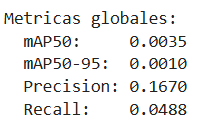

## Configuración y entrenamiendo modelo #2

In [ ]:
import shutil
from pathlib import Path
from ultralytics import YOLO

# Configuraciones optimizadas para Dermatología Facial (Texturas y Rostros)
TRAIN_CONFIG_V4 = {
    "data":        str(OUT_YAML_NEW),
    "imgsz":       640,
    "batch":       16,         # Ideal para la T4 con un modelo Medium
    "epochs":      50,
    "lr0":         0.01,       # Tasa de aprendizaje inicial
    # Eliminamos 'lrf' manual para que Ultralytics maneje el decaimiento correctamente
    "patience":    15,         # Más margen para datasets grandes
    "cls":         1.5,
    
    # ── Aumentaciones biológicas para rostros ──
    "mosaic":      0.0,        # DESACTIVADO: No queremos caras partidas en 4 partes
    "copy_paste":  0.0,        # DESACTIVADO: No queremos pegar un acné encima de una frente aleatoria
    "flipud":      0.0,        # DESACTIVADO: La gente no va al dermatólogo de cabeza
    "fliplr":      0.5,        # ACTIVADO: Espejo horizontal es excelente para simular selfies/cámaras
    "degrees":     15.0,       # Rotaciones leves de cabeza
    "translate":   0.1,        # Movimientos leves de encuadre
    "scale":       0.2,        # Zoom in/out para detectar afecciones de cerca o lejos
    
    # Ajustes de color (útil para tonos de piel y rojeces de acné)
    "hsv_h":       0.015,
    "hsv_s":       0.7,
    "hsv_v":       0.4,
    
    # ── Infraestructura Kaggle ──
    "project":     "/kaggle/working/runs",
    "name":        "dermavision_v3",
    "save":        True,
    "save_period": 5,
    "device":      0,          # Forzar tu Tesla T4 activa
    "workers":     4,          # Exprimir los 4 núcleos de CPU de Kaggle para el DataLoader
    "seed":        123,
    "verbose":     True,
    "cache":       False,
}

# Cambiamos a la versión MEDIUM (.pt se descarga solo)
model = YOLO("yolov8m.pt")

print("Iniciando entrenamiento con YOLOv8 MEDIUM...")
print(f"Clases a entrenar: {CLASSES_KEPT}")
print(f"Dataset configurado en: {OUT_YAML_NEW}")
print("-" * 50)

# Lanzar entrenamiento
results = model.train(**TRAIN_CONFIG_V4)

# ── Guardar el modelo de forma segura ──
best_src = Path("/kaggle/working/runs/dermavision_v4/weights/best.pt")
best_dst = Path("/kaggle/working/dermavision_best_v4.pt")

if best_src.exists():
    shutil.copy(best_src, best_dst)
    print(f"\n¡Éxito! Modelo guardado en: {best_dst} ({best_dst.stat().st_size/1e6:.1f} MB)")
    print("Ve al panel derecho -> Output -> descarga 'dermavision_best_v4.pt'")
else:
    print("\n[!] Alerta: No se encontró el archivo 'best.pt'. Revisa los logs de arriba.")

Iniciando entrenamiento con YOLOv8 MEDIUM...
Clases a entrenar: ['acne', 'dark circle', 'darkspot', 'dry', 'normal skin', 'oily', 'wrinkle']
Dataset configurado en: /kaggle/working/data_balanced.yaml
--------------------------------------------------
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_balanced.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, lin

In [21]:

# ── Guardar el modelo de forma segura ──
best_src = Path("/kaggle/working/runs/dermavision_v3-2/weights/best.pt")
best_dst = Path("/kaggle/working/dermavision_best_v3.pt")

if best_src.exists():
    shutil.copy(best_src, best_dst)
    print(f"\n¡Éxito! Modelo guardado en: {best_dst} ({best_dst.stat().st_size/1e6:.1f} MB)")
    print("Ve al panel derecho -> Output -> descarga 'dermavision_best_v3.pt'")
else:
    print("\n[!] Alerta: No se encontró el archivo 'best.pt'. Revisa los logs de arriba.")


¡Éxito! Modelo guardado en: /kaggle/working/dermavision_best_v3.pt (52.0 MB)
Ve al panel derecho -> Output -> descarga 'dermavision_best_v3.pt'


## Evaluacion sobre el set de test modelo 2

In [22]:
best_model = YOLO("/kaggle/working/runs/dermavision_v3-2/weights/best.pt")

# Verificar cual yaml tiene las 7 clases correctas
import yaml
with open("/kaggle/working/data_balanced.yaml") as f:
    cfg_check = yaml.safe_load(f)
print(f"Clases en data_balanced.yaml ({cfg_check['nc']}): {cfg_check['names']}")

print("\nEvaluando sobre TEST set...")
metrics = best_model.val(
    data    = "/kaggle/working/data_balanced.yaml",  
    split   = "test",
    imgsz   = 640,
    batch   = 16,
    device  = 0,
    conf    = 0.35,
    iou     = 0.45,
    verbose = True,
)

CLASSES_KEPT = ['acne','dark circle','darkspot','dry','normal skin','oily','wrinkle']

print("\nMetricas globales:")
print(f"  mAP50:     {metrics.box.map50:.4f}")
print(f"  mAP50-95:  {metrics.box.map:.4f}")
print(f"  Precision: {metrics.box.mp:.4f}")
print(f"  Recall:    {metrics.box.mr:.4f}")
print()
print("mAP50 por clase:")
for cls, ap in zip(CLASSES_KEPT, metrics.box.ap50):
    bar  = "#" * int(ap * 30)
    print(f"  {cls:15s}  {ap:.3f}  {bar}{flag}")

Clases en data_balanced.yaml (7): ['acne', 'dark circle', 'darkspot', 'dry', 'normal skin', 'oily', 'wrinkle']

Evaluando sobre TEST set...
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,843,813 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1896.5±676.1 MB/s, size: 75.3 KB)
val: Scanning /kaggle/working/data_balanced/test/labels... 377 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 377/377 1.3Kit/s 0.3s<0.2s
val: New cache created: /kaggle/working/data_balanced/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.1it/s 11.3s0.5s
                   all        377       1555      0.282      0.131     0.0768     0.0363
                  acne        248       1152      0.398      0.046     0.0223    0.00781
           dark circle         26         42      0.632      0.286      0.203     0.091

NameError: name 'flag' is not defined

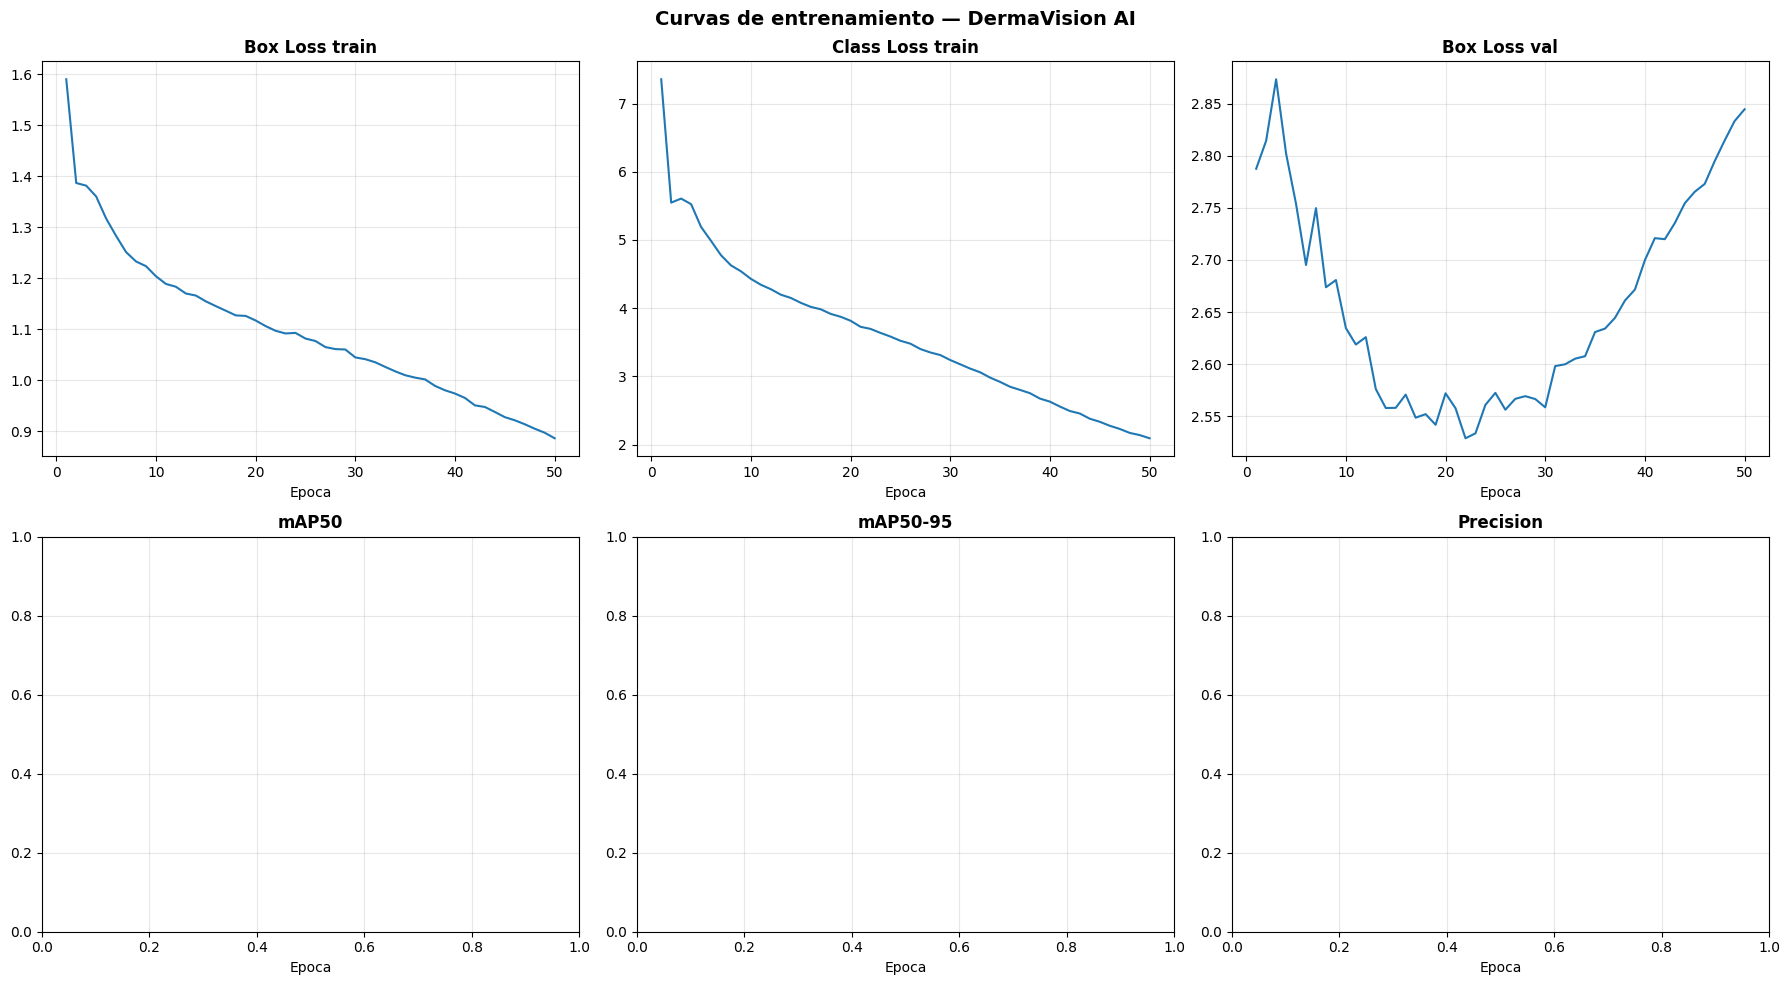

In [23]:
# Curvas de entrenamiento
import pandas as pd

results_csv = Path("/kaggle/working/runs/dermavision_v3-2/results.csv")
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Curvas de entrenamiento — DermaVision AI",
                 fontsize=14, fontweight="bold")

    plots = [
        ("train/box_loss",   "Box Loss train",   axes[0,0]),
        ("train/cls_loss",   "Class Loss train", axes[0,1]),
        ("val/box_loss",     "Box Loss val",     axes[0,2]),
        ("metrics/mAP50",    "mAP50",             axes[1,0]),
        ("metrics/mAP50-95", "mAP50-95",          axes[1,1]),
        ("metrics/precision","Precision",         axes[1,2]),
    ]
    for col, title, ax in plots:
        if col in df.columns:
            ax.plot(df["epoch"], df[col], linewidth=1.5)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoca")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

## Configuración y entrenamiento modelo # 3

Estimamos otro modelo eliminando las clases minoritarias

In [32]:
# Crear una copia del dataset en working para poder modificarlo
# (el original en /kaggle/input es de solo lectura)
CLEAN_PATH = WORKING / "data_balanced2"

if CLEAN_PATH.exists():
    shutil.rmtree(CLEAN_PATH)

print("Copiando dataset a /kaggle/working/data_balanced2 ...")
shutil.copytree(DATASET_PATH, CLEAN_PATH)
print("Copia completada.")

# Verificar
for split in ["train", "valid", "test"]:
    n = len(list((CLEAN_PATH / split / "images").glob("*.jpg")))
    print(f"  {split}: {n} imagenes")

Copiando dataset a /kaggle/working/data_balanced2 ...
Copia completada.
  train: 44387 imagenes
  valid: 866 imagenes
  test: 412 imagenes


In [ ]:
# Clases a eliminar completamente
CLASSES_TO_DROP = {
    6,   # pores       (440 anotaciones)
    7,   # skin redness (376 anotaciones)
}

# Clases a reducir por undersampling
CLASSES_TO_UNDERSAMPLE = {
    0: 1100,  
    1: 1100,
    2: 1100,
    3: 1100,
    4: 1100,
    5: 1100,
    8: 1100,
}

SEED = 123
random.seed(SEED)

img_dir = CLEAN_PATH / "train" / "images"
lbl_dir = CLEAN_PATH / "train" / "labels"

# ── Paso 1: eliminar clases con pocas muestras 
# Para cada archivo de labels, eliminar las lineas de las clases descartadas.
# Si el archivo queda vacio (la imagen solo tenia esas clases),
# eliminar tambien la imagen.

print("Paso 1: eliminando clases con pocas muestras...")
imgs_removed_drop = 0
anns_removed_drop = 0

for lbl_path in tqdm(list(lbl_dir.glob("*.txt")), desc="Filtrando clases"):
    with open(lbl_path) as f:
        lines = [l.strip() for l in f if l.strip()]

    kept = [l for l in lines if int(l.split()[0]) not in CLASSES_TO_DROP]
    removed = len(lines) - len(kept)
    anns_removed_drop += removed

    if not kept:
        # imagen solo tenia clases descartadas -> eliminar imagen y label
        lbl_path.unlink(missing_ok=True)
        for ext in [".jpg", ".png"]:
            ip = img_dir / (lbl_path.stem + ext)
            if ip.exists():
                ip.unlink()
                imgs_removed_drop += 1
                break
    else:
        with open(lbl_path, "w") as f:
            f.write("\n".join(kept))

print(f"  Anotaciones eliminadas: {anns_removed_drop}")
print(f"  Imagenes eliminadas:    {imgs_removed_drop}")

Paso 1: eliminando clases con pocas muestras...


Filtrando clases: 100%|██████████| 3316/3316 [00:00<00:00, 11558.28it/s]

  Anotaciones eliminadas: 0
  Imagenes eliminadas:    0


In [ ]:
#  Paso 2: undersampling de normal_skin y dark_circle 
# Identificar imagenes que contienen SOLO la clase a reducir
# (las imagenes mixtas se conservan para no perder otras clases).

print("\nPaso 2: undersampling...")

for class_id, target in CLASSES_TO_UNDERSAMPLE.items():
    class_name = ['acne','dark circle','darkspot','dry','normal skin',
                  'oily','pores','skin redness','wrinkle'][class_id]

    # Separar imagenes solo-clase de imagenes mixtas
    solo  = []   # solo tienen esta clase -> candidatas a eliminar
    mixed = []   # tienen esta + otras clases -> conservar siempre

    for lbl_path in lbl_dir.glob("*.txt"):
        with open(lbl_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        ids = set(int(l.split()[0]) for l in lines)
        if ids == {class_id}:
            solo.append(lbl_path)
        elif class_id in ids:
            mixed.append(lbl_path)

    # Contar anotaciones en cada grupo
    count_solo  = sum(
        sum(1 for l in open(p) if l.strip().split()[0] == str(class_id))
        for p in solo
    )
    count_mixed = sum(
        sum(1 for l in open(p) if l.strip().split()[0] == str(class_id))
        for p in mixed
    )

    print(f"\n  {class_name}:")
    print(f"    Solo-clase: {count_solo} anotaciones en {len(solo)} imagenes")
    print(f"    Mixtas:     {count_mixed} anotaciones (no se tocan)")

    # Cuantas anotaciones solo-clase necesitamos conservar
    to_keep_from_solo = max(0, target - count_mixed)
    print(f"    Objetivo total: {target} -> conservar {to_keep_from_solo} de solo-clase")

    if to_keep_from_solo >= count_solo:
        print(f"    Ya tiene <= {target}. Sin cambios.")
        continue

    # Eliminar el excedente aleatoriamente
    random.shuffle(solo)
    kept_count = 0
    removed    = 0

    for lbl_path in solo:
        n = sum(1 for l in open(lbl_path) if l.strip().split()[0] == str(class_id))
        if kept_count + n <= to_keep_from_solo:
            kept_count += n
        else:
            lbl_path.unlink(missing_ok=True)
            for ext in [".jpg", ".png"]:
                ip = img_dir / (lbl_path.stem + ext)
                if ip.exists():
                    ip.unlink()
                    break
            removed += 1

    print(f"    Eliminadas: {removed} imagenes")


Paso 2: undersampling...

  acne:
    Solo-clase: 508 anotaciones en 88 imagenes
    Mixtas:     592 anotaciones (no se tocan)
    Objetivo total: 1100 -> conservar 508 de solo-clase
    Ya tiene <= 1100. Sin cambios.

  dark circle:
    Solo-clase: 0 anotaciones en 0 imagenes
    Mixtas:     2008 anotaciones (no se tocan)
    Objetivo total: 1100 -> conservar 0 de solo-clase
    Ya tiene <= 1100. Sin cambios.

  darkspot:
    Solo-clase: 371 anotaciones en 102 imagenes
    Mixtas:     729 anotaciones (no se tocan)
    Objetivo total: 1100 -> conservar 371 de solo-clase
    Ya tiene <= 1100. Sin cambios.

  dry:
    Solo-clase: 1678 anotaciones en 778 imagenes
    Mixtas:     111 anotaciones (no se tocan)
    Objetivo total: 1100 -> conservar 989 de solo-clase
    Eliminadas: 304 imagenes

  normal skin:
    Solo-clase: 929 anotaciones en 929 imagenes
    Mixtas:     171 anotaciones (no se tocan)
    Objetivo total: 1100 -> conservar 929 de solo-clase
    Ya tiene <= 1100. Sin cambios

In [ ]:
# Paso 3: verificar distribucion final 
from collections import defaultdict

CLASSES_KEPT = ['acne','dark circle','darkspot','dry',
                'normal skin','oily','wrinkle']

# Remapar IDs: eliminar pores(6) y skin_redness(7)
# Los IDs que quedan: 0,1,2,3,4,5,8 -> remapar a 0,1,2,3,4,5,6
ID_REMAP = {0:0, 1:1, 2:2, 3:3, 4:4, 5:5, 8:6}

counts_new = defaultdict(int)
for lbl_path in lbl_dir.glob("*.txt"):
    for line in open(lbl_path):
        p = line.strip().split()
        if p:
            counts_new[int(p[0])] += 1

print("Distribucion tras balanceo (IDs originales):")
total_new = sum(counts_new.values())
for orig_id, new_id in ID_REMAP.items():
    n   = counts_new[orig_id]
    pct = 100 * n / total_new if total_new else 0
    bar = "#" * int(pct / 2)
    print(f"  [{orig_id}] {CLASSES_KEPT[new_id]:15s} {n:6d}  {pct:5.1f}%  {bar}")

ratio = max(counts_new.values()) / max(min(
    v for v in counts_new.values() if v > 0), 1)
print(f"\nTotal anotaciones: {total_new:,}")
print(f"Ratio desbalance:  {ratio:.1f}x")

Distribucion tras balanceo (IDs originales):
  [0] acne              1100   12.8%  ######
  [1] dark circle       2008   23.3%  ###########
  [2] darkspot          1100   12.8%  ######
  [3] dry               1100   12.8%  ######
  [4] normal skin       1100   12.8%  ######
  [5] oily              1100   12.8%  ######
  [8] wrinkle           1100   12.8%  ######

Total anotaciones: 8,608
Ratio desbalance:  1.8x


In [ ]:
#Paso 4: remapar IDs en todos los labels 
# Como eliminamos pores(6) y skin_redness(7), los IDs deben reordenarse:
# 0->0, 1->1, 2->2, 3->3, 4->4, 5->5, 8->6
# (wrinkle pasa de ID 8 a ID 6)

print("Remapeando IDs de clase en labels...")

for split in ["train", "valid", "test"]:
    lbl_dir_s = CLEAN_PATH / split / "labels"
    modified  = 0
    removed   = 0

    for lbl_path in tqdm(list(lbl_dir_s.glob("*.txt")),
                         desc=f"  Remap {split}", leave=False):
        with open(lbl_path) as f:
            lines = [l.strip() for l in f if l.strip()]

        new_lines = []
        for line in lines:
            parts  = line.split()
            old_id = int(parts[0])
            new_id = ID_REMAP.get(old_id)
            if new_id is not None:
                new_lines.append(f"{new_id} {' '.join(parts[1:])}")

        if not new_lines:
            lbl_path.unlink(missing_ok=True)
            for ext in [".jpg", ".png"]:
                ip = (CLEAN_PATH / split / "images" /
                      (lbl_path.stem + ext))
                if ip.exists():
                    ip.unlink()
                    removed += 1
                    break
        else:
            with open(lbl_path, "w") as f:
                f.write("\n".join(new_lines))
            modified += 1

    print(f"  {split}: {modified} labels actualizados, {removed} imagenes eliminadas")

Remapeando IDs de clase en labels...


  train: 3012 labels actualizados, 0 imagenes eliminadas


  valid: 727 labels actualizados, 139 imagenes eliminadas


  test: 377 labels actualizados, 35 imagenes eliminadas


In [ ]:
#  Paso 5: crear data.yaml final con 7 clases 
import yaml

# Recalcular class weights con la nueva distribucion
counts_final = defaultdict(int)
for lbl_path in (CLEAN_PATH / "train" / "labels").glob("*.txt"):
    for line in open(lbl_path):
        p = line.strip().split()
        if p:
            counts_final[int(p[0])] += 1

N_NEW   = 7
total_f = sum(counts_final[i] for i in range(N_NEW))
raw_w   = [total_f / (N_NEW * max(counts_final.get(i,1),1))
           for i in range(N_NEW)]
mean_w  = sum(raw_w) / N_NEW
weights = [min(round(w / mean_w, 4), 10.0) for w in raw_w]

cfg_new = {
    "path":   str(CLEAN_PATH),
    "train":  "train/images",
    "val":    "valid/images",
    "test":   "test/images",
    "nc":     N_NEW,
    "names":  CLASSES_KEPT,
    "weight": weights,
}

OUT_YAML_NEW = WORKING / "data_balanced2.yaml"
with open(OUT_YAML_NEW, "w") as f:
    yaml.dump(cfg_new, f, default_flow_style=False, allow_unicode=True)

print("data_balanced2.yaml creado:")
print(f"  Clases ({N_NEW}): {CLASSES_KEPT}")
print(f"  Weights: {weights}")

# Resumen final
print("\nDistribucion final del dataset:")
for i, cls in enumerate(CLASSES_KEPT):
    n   = counts_final[i]
    pct = 100 * n / total_f
    bar = "#" * int(pct / 2)
    print(f"  [{i}] {cls:15s} {n:6d}  {pct:5.1f}%  {bar}")

ratio_f = max(counts_final.values()) / max(
    min(counts_final.values()), 1)
print(f"\nRatio desbalance final: {ratio_f:.1f}x")

data_balanced2.yaml creado:
  Clases (7): ['acne', 'dark circle', 'darkspot', 'dry', 'normal skin', 'oily', 'wrinkle']
  Weights: [1.0691, 0.5856, 1.0691, 1.0691, 1.0691, 1.0691, 1.0691]

Distribucion final del dataset:
  [0] acne              1100   12.8%  ######
  [1] dark circle       2008   23.3%  ###########
  [2] darkspot          1100   12.8%  ######
  [3] dry               1100   12.8%  ######
  [4] normal skin       1100   12.8%  ######
  [5] oily              1100   12.8%  ######
  [6] wrinkle           1100   12.8%  ######

Ratio desbalance final: 1.8x


In [ ]:


# Configuraciones optimizadas para Dermatología Facial (Texturas y Rostros)
TRAIN_CONFIG_V4 = {
    "data":        str(OUT_YAML_NEW),
    "imgsz":       640,
    "batch":       16,         # Ideal para la T4 con un modelo Medium
    "epochs":      50,
    "lr0":         0.01,       # Tasa de aprendizaje inicial
    # Eliminamos 'lrf' manual para que Ultralytics maneje el decaimiento correctamente
    "patience":    15,         # Más margen para datasets grandes
    "cls":         1.5,
    
    # ── Aumentaciones biológicas para rostros ──
    "mosaic":      0.0,        # DESACTIVADO: No queremos caras partidas en 4 partes
    "copy_paste":  0.0,        # DESACTIVADO: No queremos pegar un acné encima de una frente aleatoria
    "flipud":      0.0,        # DESACTIVADO: La gente no va al dermatólogo de cabeza
    "fliplr":      0.5,        # ACTIVADO: Espejo horizontal es excelente para simular selfies/cámaras
    "degrees":     15.0,       # Rotaciones leves de cabeza
    "translate":   0.1,        # Movimientos leves de encuadre
    "scale":       0.2,        # Zoom in/out para detectar afecciones de cerca o lejos
    
    # Ajustes de color (útil para tonos de piel y rojeces de acné)
    "hsv_h":       0.015,
    "hsv_s":       0.7,
    "hsv_v":       0.4,
    
    # ── Infraestructura Kaggle ──
    "project":     "/kaggle/working/runs",
    "name":        "dermavision_v3",
    "save":        True,
    "save_period": 5,
    "device":      0,          # Forzar tu Tesla T4 activa
    "workers":     4,          # Exprimir los 4 núcleos de CPU de Kaggle para el DataLoader
    "seed":        123,
    "verbose":     True,
    "cache":       False,
}

# Cambiamos a la versión MEDIUM (.pt se descarga solo)
model = YOLO("yolov8m.pt")

print("Iniciando entrenamiento con YOLOv8 MEDIUM...")
print(f"Clases a entrenar: {CLASSES_KEPT}")
print(f"Dataset configurado en: {OUT_YAML_NEW}")
print("-" * 50)

# Lanzar entrenamiento
results = model.train(**TRAIN_CONFIG_V4)

# ── Guardar el modelo de forma segura ──
best_src = Path("/kaggle/working/runs/dermavision_v3-2/weights/best.pt")
best_dst = Path("/kaggle/working/dermavision_best_v4.pt")

if best_src.exists():
    shutil.copy(best_src, best_dst)
    print(f"\n¡Éxito! Modelo guardado en: {best_dst} ({best_dst.stat().st_size/1e6:.1f} MB)")
    print("Ve al panel derecho -> Output -> descarga 'dermavision_best_v4.pt'")
else:
    print("\n[!] Alerta: No se encontró el archivo 'best.pt'. Revisa los logs de arriba.")

Iniciando entrenamiento con YOLOv8 MEDIUM...
Clases a entrenar: ['acne', 'dark circle', 'darkspot', 'dry', 'normal skin', 'oily', 'wrinkle']
Dataset configurado en: /kaggle/working/data_balanced2.yaml
--------------------------------------------------
New https://pypi.org/project/ultralytics/8.4.60 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_balanced2.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, ha

In [ ]:
#  Guardar el modelo de forma segura 
best_src = Path("/kaggle/working/runs/dermavision_v3-3/weights/best.pt")
best_dst = Path("/kaggle/working/dermavision_best_v4.pt")

if best_src.exists():
    shutil.copy(best_src, best_dst)
    print(f"\n¡Éxito! Modelo guardado en: {best_dst} ({best_dst.stat().st_size/1e6:.1f} MB)")
    print("Ve al panel derecho -> Output -> descarga 'dermavision_best_v4.pt'")
else:
    print("\n[!] Alerta: No se encontró el archivo 'best.pt'. Revisa los logs de arriba.")


¡Éxito! Modelo guardado en: /kaggle/working/dermavision_best_v4.pt (52.0 MB)
Ve al panel derecho -> Output -> descarga 'dermavision_best_v4.pt'


In [47]:
best_model = YOLO("/kaggle/working/runs/dermavision_v3-3/weights/best.pt")

# Verificar cual yaml tiene las 7 clases correctas
import yaml
with open("/kaggle/working/data_balanced.yaml") as f:
    cfg_check = yaml.safe_load(f)
print(f"Clases en data_balanced.yaml ({cfg_check['nc']}): {cfg_check['names']}")

print("\nEvaluando sobre TEST set...")
metrics = best_model.val(
    data    = "/kaggle/working/data_balanced.yaml",  
    split   = "test",
    imgsz   = 640,
    batch   = 16,
    device  = 0,
    conf    = 0.35,
    iou     = 0.45,
    verbose = True,
)

CLASSES_KEPT = ['acne','dark circle','darkspot','dry','normal skin','oily','wrinkle']

print("\nMetricas globales:")
print(f"  mAP50:     {metrics.box.map50:.4f}")
print(f"  mAP50-95:  {metrics.box.map:.4f}")
print(f"  Precision: {metrics.box.mp:.4f}")
print(f"  Recall:    {metrics.box.mr:.4f}")
print()
print("mAP50 por clase:")
for cls, ap in zip(CLASSES_KEPT, metrics.box.ap50):
    bar  = "#" * int(ap * 30)
    print(f"  {cls:15s}  {ap:.3f}  {bar}{flag}")

Clases en data_balanced.yaml (7): ['acne', 'dark circle', 'darkspot', 'dry', 'normal skin', 'oily', 'wrinkle']

Evaluando sobre TEST set...
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,843,813 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 766.9±783.1 MB/s, size: 84.5 KB)
val: Scanning /kaggle/working/data_balanced/test/labels... 372 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 372/372 1.3Kit/s 0.3s<0.2s
val: New cache created: /kaggle/working/data_balanced/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.2it/s 10.8s0.4s
                   all        372       1507      0.143      0.006    0.00373    0.00236
                  acne        248       1152        0.5   0.000868      0.005     0.0035
           dark circle         26         42          0          0          0          0

NameError: name 'flag' is not defined

Por tiempo, se elige el modelo que mejores resultados dio que es el modelo #2 sin embargo este modelo tiene mucho que mejorar